# Práctica numérica 2 - AV18012

## Dispersión en un potencial bidimensional

Este notebook reúne en un solo documento la derivación analítica, la implementación numérica y el análisis de resultados de la práctica.

Trabajaremos con el potencial

$$
V(x,y) = s\, x^2 y^2 e^{-(x^2+y^2)}, \qquad s\in\{+1,-1\},
$$

donde `s = +1` representa el caso repulsivo y `s = -1` el caso atractivo.

## Sobre la velocidad de entrada en x

El enunciado dice que la partícula incidente entra con velocidad en la dirección `x`, pero en la lista de parámetros sugeridos aparece `v_y(0)=0.5` y `v_x(0)=0.0`, en este notebook se adopta la convención físicamente estándar de incidencia desde la izquierda:

- `x(0) = x0 < 0` con `|x0|` suficientemente grande.
- `y(0) = b`, donde `b` es el parámetro de impacto.
- `v_x(0) > 0` y `v_y(0) = 0`.

Por coherencia con esta convención, aquí se usa

$$
\theta = \operatorname{atan2}(v_y, v_x),
$$

que es la forma natural cuando la velocidad incidente inicial apunta en `+x`.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

import fcl1109 as fcl

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["image.cmap"] = "coolwarm"

## Derivación analítica

Partimos de la fuerza

$$
\vec F = -\nabla V.
$$

Si definimos

$$
V(x,y)= s\,x^2 y^2 e^{-(x^2+y^2)},
$$

entonces

$$
\frac{\partial V}{\partial x} = s\,2xy^2(1-x^2)e^{-(x^2+y^2)},
$$

$$
\frac{\partial V}{\partial y} = s\,2x^2y(1-y^2)e^{-(x^2+y^2)}.
$$

Por tanto,

$$
F_x = -\frac{\partial V}{\partial x} = -s\,2xy^2(1-x^2)e^{-(x^2+y^2)},
$$

$$
F_y = -\frac{\partial V}{\partial y} = -s\,2x^2y(1-y^2)e^{-(x^2+y^2)}.
$$

Usando $m\ddot x = F_x$ y $m\ddot y = F_y$, obtenemos

$$
\ddot x = -\frac{s}{m}2xy^2(1-x^2)e^{-(x^2+y^2)},
\qquad
\ddot y = -\frac{s}{m}2x^2y(1-y^2)e^{-(x^2+y^2)}.
$$

Esto coincide con el enunciado al identificar el signo superior e inferior según el valor de `s`.

Además, en los puntos $x=\pm 1$, $y=\pm 1$ se anulan los factores $(1-x^2)$ y $(1-y^2)$, así que la fuerza desaparece allí. En esos puntos

$$
V_{\max} = s\,(1)(1)e^{-2} = \pm e^{-2}.
$$

In [7]:
def potencial(x, y, signo=1.0):
    return signo * x**2 * y**2 * np.exp(-(x**2 + y**2))


def fuerza(x, y, signo=1.0):
    exp_factor = np.exp(-(x**2 + y**2))
    fx = -signo * 2.0 * x * y**2 * (1.0 - x**2) * exp_factor
    fy = -signo * 2.0 * x**2 * y * (1.0 - y**2) * exp_factor
    return np.array([fx, fy])


def sistema_particula(t, estado, masa=0.5, signo=1.0):
    x, y, vx, vy = estado
    fx, fy = fuerza(x, y, signo=signo)
    ax = fx / masa
    ay = fy / masa
    return np.array([vx, vy, ax, ay], dtype=float)


def energia_cinetica(vx, vy, masa=0.5):
    return 0.5 * masa * (vx**2 + vy**2)


def energia_total(estado, masa=0.5, signo=1.0):
    x, y, vx, vy = estado
    return energia_cinetica(vx, vy, masa=masa) + potencial(x, y, signo=signo)


def cociente_interaccion(estado, masa=0.5, signo=1.0):
    x, y, vx, vy = estado
    ke = energia_cinetica(vx, vy, masa=masa)
    pe = abs(potencial(x, y, signo=signo))
    if ke == 0.0:
        return np.inf
    return pe / ke


def integrar_trayectoria(
    estado_inicial,
    dt=0.01,
    t_max=80.0,
    masa=0.5,
    signo=1.0,
    umbral_salida=1e-6,
    pasos_minimos=100,
    radio_escape=8.0,
    ):
    n_pasos = int(np.ceil(t_max / dt))
    tiempos = np.empty(n_pasos + 1)
    estados = np.empty((n_pasos + 1, 4))
    tiempos[0] = 0.0
    estados[0] = np.array(estado_inicial, dtype=float)

    t = 0.0
    estado = np.array(estado_inicial, dtype=float)

    for i in range(1, n_pasos + 1):
        estado = fcl.rk4(
            lambda tau, s: sistema_particula(tau, s, masa=masa, signo=signo),
            t,
            estado,
            dt,
        )
        t = i * dt
        tiempos[i] = t
        estados[i] = estado

        fuera_de_region = np.hypot(estado[0], estado[1]) >= radio_escape
        interaccion_debil = cociente_interaccion(estado, masa=masa, signo=signo) <= umbral_salida

        if i >= pasos_minimos and fuera_de_region and interaccion_debil:
            return tiempos[: i + 1], estados[: i + 1]

    return tiempos, estados


def angulo_dispersion(estado_final):
    vx, vy = estado_final[2], estado_final[3]
    return np.arctan2(vy, vx)

## Visualización del potencial

Con esto cubrimos el apartado (a). Mostramos mapas de calor para los casos repulsivo y atractivo, y además verificamos visualmente la ubicación de los máximos en $(\pm 1, \pm 1)$.

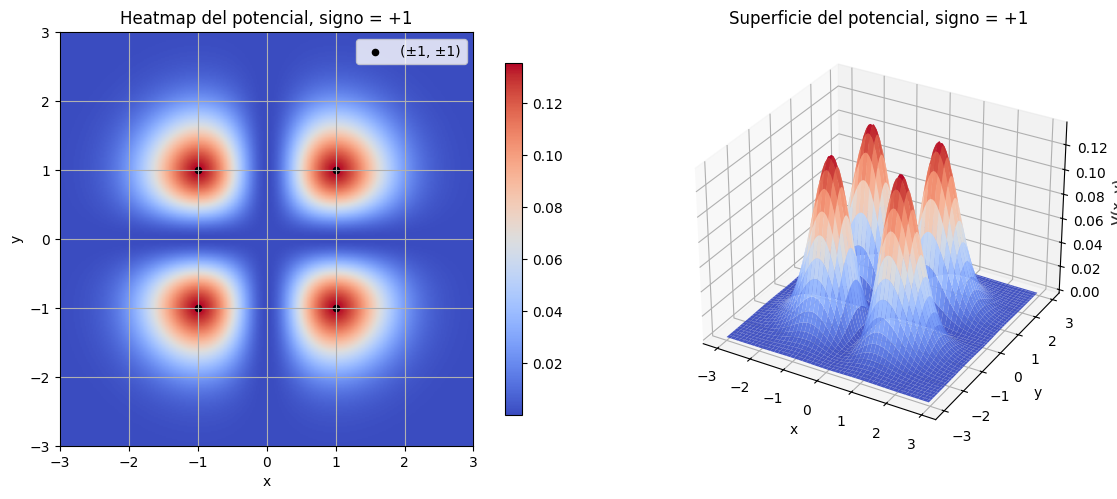

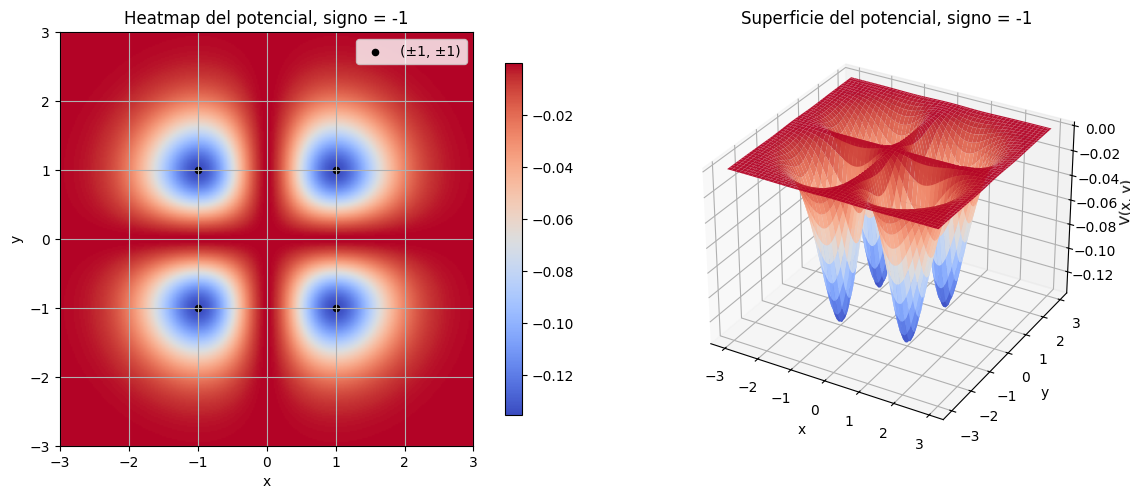

In [8]:
def malla_potencial(limite=3.0, n=300):
    eje = np.linspace(-limite, limite, n)
    x, y = np.meshgrid(eje, eje)
    return eje, x, y


def graficar_potencial(signo, limite=3.0, n=300):
    eje, x, y = malla_potencial(limite=limite, n=n)
    z = potencial(x, y, signo=signo)

    fig = plt.figure(figsize=(13, 5))
    ax1 = fig.add_subplot(1, 2, 1)
    im = ax1.imshow(
        z,
        extent=[eje[0], eje[-1], eje[0], eje[-1]],
        origin="lower",
        aspect="equal",
    )
    ax1.scatter([1, 1, -1, -1], [1, -1, 1, -1], c="k", s=20, label="(±1, ±1)")
    ax1.set_title(f"Heatmap del potencial, signo = {signo:+.0f}")
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    ax1.legend(loc="upper right")
    fig.colorbar(im, ax=ax1, shrink=0.85)

    ax2 = fig.add_subplot(1, 2, 2, projection="3d")
    paso = max(1, n // 80)
    ax2.plot_surface(
        x[::paso, ::paso],
        y[::paso, ::paso],
        z[::paso, ::paso],
        cmap="coolwarm",
        linewidth=0,
        antialiased=True,
        alpha=0.95,
    )
    ax2.set_title(f"Superficie del potencial, signo = {signo:+.0f}")
    ax2.set_xlabel("x")
    ax2.set_ylabel("y")
    ax2.set_zlabel("V(x, y)")
    plt.tight_layout()
    plt.show()


graficar_potencial(signo=1.0)
graficar_potencial(signo=-1.0)

### Lectura física del cambio de signo (literal a)

- Para `s = +1`, el potencial toma valores positivos con máximos en $(\pm 1, \pm 1)$: esas zonas actúan como "colinas" y tienden a desviar la partícula (carácter repulsivo).
- Para `s = -1`, el potencial invierte su signo y aparecen mínimos en los mismos puntos: esas zonas actúan como "pozos" y favorecen captura transitoria o rodeos (carácter atractivo).
- La geometría espacial de los extremos se conserva, pero se invierte su efecto dinámico sobre las trayectorias.

## Parámetros numéricos y funciones de apoyo

Aquí fijamos una configuración base reutilizable para los apartados (e), (i), (k) y (l). El valor de `x0` se elige suficientemente lejos para que inicialmente se cumpla $|V|/K \ll 1$.

In [9]:
VMAX = np.exp(-2.0)

parametros_base = {
    "masa": 0.5,
    "x0": -6.0,
    "dt": 0.01,
    "t_max": 120.0,
    "umbral_salida": 1e-6,
    "radio_escape": 8.0,
}


def estado_inicial_desde_b(b, energia, masa=0.5, x0=-6.0):
    vx0 = np.sqrt(2.0 * energia / masa)
    return np.array([x0, b, vx0, 0.0], dtype=float)


def verificar_condicion_inicial(b, energia, signo=1.0, masa=0.5, x0=-6.0):
    estado0 = estado_inicial_desde_b(b=b, energia=energia, masa=masa, x0=x0)
    return cociente_interaccion(estado0, masa=masa, signo=signo)


def tiempo_libre(x0, x_final, energia, masa=0.5):
    vx0 = np.sqrt(2.0 * energia / masa)
    return (x_final - x0) / vx0


def retardo_temporal(tiempos, estados, energia, masa=0.5, x0=-6.0):
    x_final = estados[-1, 0]
    return tiempos[-1] - tiempo_libre(x0=x0, x_final=x_final, energia=energia, masa=masa)


def simular_impactos(b_values, energia, signo=1.0, **kwargs):
    resultados = []
    masa = kwargs.get("masa", parametros_base["masa"])
    x0 = kwargs.get("x0", parametros_base["x0"])

    for b in b_values:
        estado0 = estado_inicial_desde_b(b=b, energia=energia, masa=masa, x0=x0)
        tiempos, estados = integrar_trayectoria(
            estado0,
            dt=kwargs.get("dt", parametros_base["dt"]),
            t_max=kwargs.get("t_max", parametros_base["t_max"]),
            masa=masa,
            signo=signo,
            umbral_salida=kwargs.get("umbral_salida", parametros_base["umbral_salida"]),
            radio_escape=kwargs.get("radio_escape", parametros_base["radio_escape"]),
        )
        resultados.append(
            {
                "b": b,
                "tiempos": tiempos,
                "estados": estados,
                "theta": angulo_dispersion(estados[-1]),
                "retardo": retardo_temporal(tiempos, estados, energia=energia, masa=masa, x0=x0),
                "energia_final": energia_total(estados[-1], masa=masa, signo=signo),
            }
        )

    return resultados


for energia in (0.5 * VMAX, 2.0 * VMAX):
    razon = verificar_condicion_inicial(
        b=1.0,
        energia=energia,
        signo=1.0,
        masa=parametros_base["masa"],
        x0=parametros_base["x0"],
    )
    print(f"E = {energia:.5f}, |V|/K inicial maximo estimado = {razon:.3e}")

E = 0.06767, |V|/K inicial maximo estimado = 4.540e-14
E = 0.27067, |V|/K inicial maximo estimado = 1.135e-14


## Trayectorias de prueba y espacio de fases

Esta sección cubre una primera parte de los apartados (g) y (h). Usamos algunos valores representativos de `b` para comparar trayectorias suaves con otras más sensibles al parámetro de impacto.

### Trayectorias superpuestas sobre mapas de calor (literal g)

En estas figuras se superponen trayectorias sobre el potencial para visualizar directamente cómo el paisaje energético modifica la dispersión.

Se usa el barrido completo sugerido en el literal (f):

$$
b \in [-1,1], \qquad \Delta b = 0.05.
$$

Eso produce 41 trayectorias por panel. Para no saturar la figura, algunas trayectorias representativas se resaltan con etiqueta.

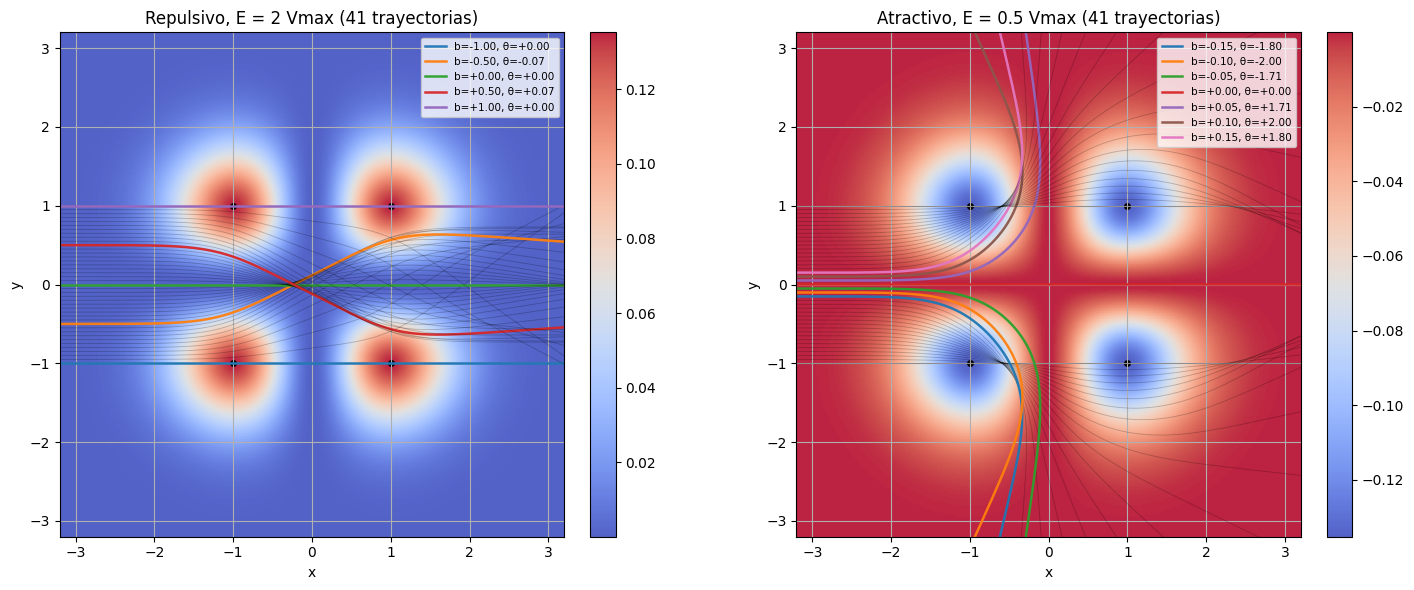

In [10]:
def graficar_mapa_con_trayectorias(
    ax,
    signo,
    energia,
    b_values,
    titulo,
    limite=3.2,
    n=320,
    dt=0.01,
    t_max=80.0,
    destacar=None,
    ):
    eje = np.linspace(-limite, limite, n)
    xg, yg = np.meshgrid(eje, eje)
    zg = potencial(xg, yg, signo=signo)

    im = ax.imshow(
        zg,
        extent=[eje[0], eje[-1], eje[0], eje[-1]],
        origin="lower",
        aspect="equal",
        alpha=0.88,
    )

    destacar = destacar or []
    destacar_set = set(np.round(np.array(destacar, dtype=float), 3))
    param_plot = {**parametros_base, "dt": dt, "t_max": t_max}

    for b in b_values:
        res = simular_impactos([b], energia=energia, signo=signo, **param_plot)[0]
        est = res["estados"]
        b_key = np.round(float(b), 3)

        if b_key in destacar_set:
            ax.plot(
                est[:, 0],
                est[:, 1],
                lw=1.8,
                alpha=0.95,
                label=f"b={b:+.2f}, θ={res['theta']:+.2f}",
            )
        else:
            ax.plot(est[:, 0], est[:, 1], color="k", lw=0.6, alpha=0.22)

    ax.scatter([1, 1, -1, -1], [1, -1, 1, -1], c="k", s=16)
    ax.set_xlim(-limite, limite)
    ax.set_ylim(-limite, limite)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(titulo)
    if len(destacar) > 0:
        ax.legend(fontsize=7.5, loc="upper right")
    return im


b_g = np.arange(-1.0, 1.0001, 0.05)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

im1 = graficar_mapa_con_trayectorias(
    axes[0],
    signo=+1.0,
    energia=2.0 * VMAX,
    b_values=b_g,
    titulo="Repulsivo, E = 2 Vmax (41 trayectorias)",
    destacar=[-1.0, -0.5, 0.0, 0.5, 1.0],
)

im2 = graficar_mapa_con_trayectorias(
    axes[1],
    signo=-1.0,
    energia=0.5 * VMAX,
    b_values=b_g,
    titulo="Atractivo, E = 0.5 Vmax (41 trayectorias)",
    destacar=[-0.15, -0.10, -0.05, 0.00, 0.05, 0.10, 0.15],
)

fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

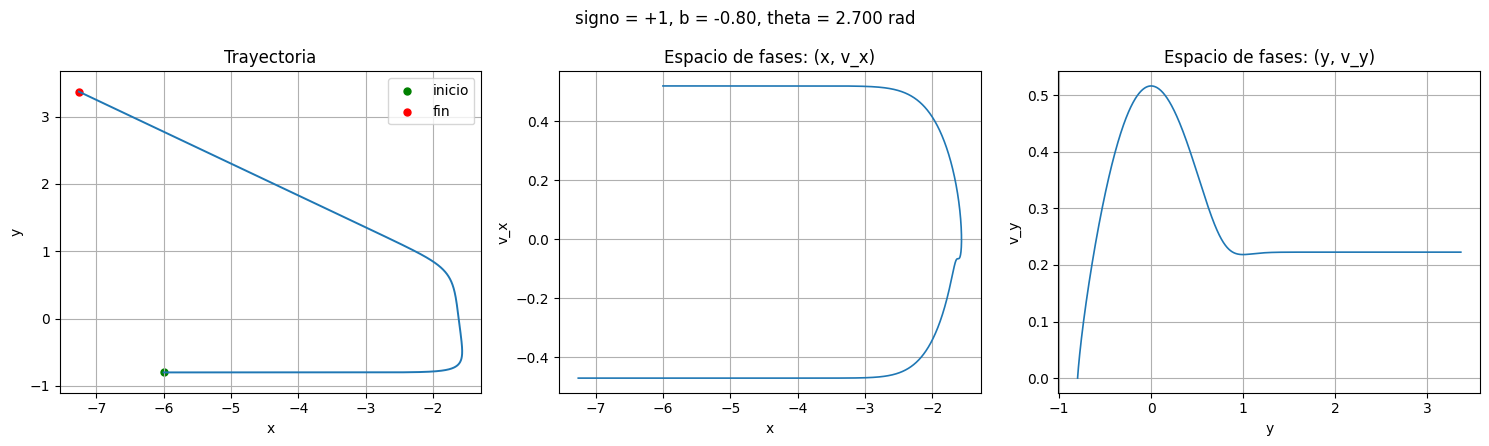

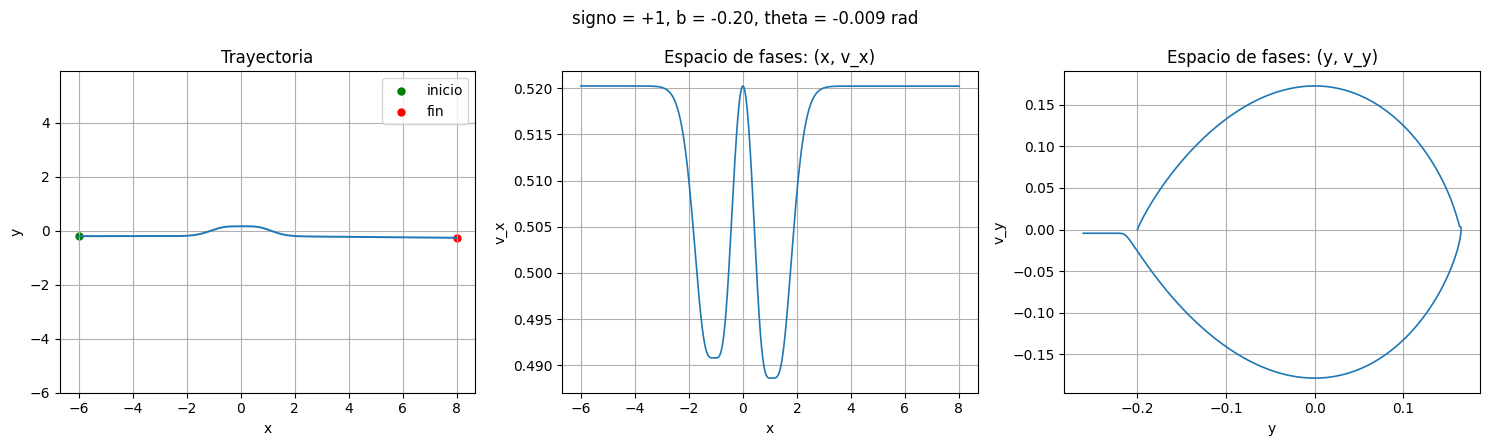

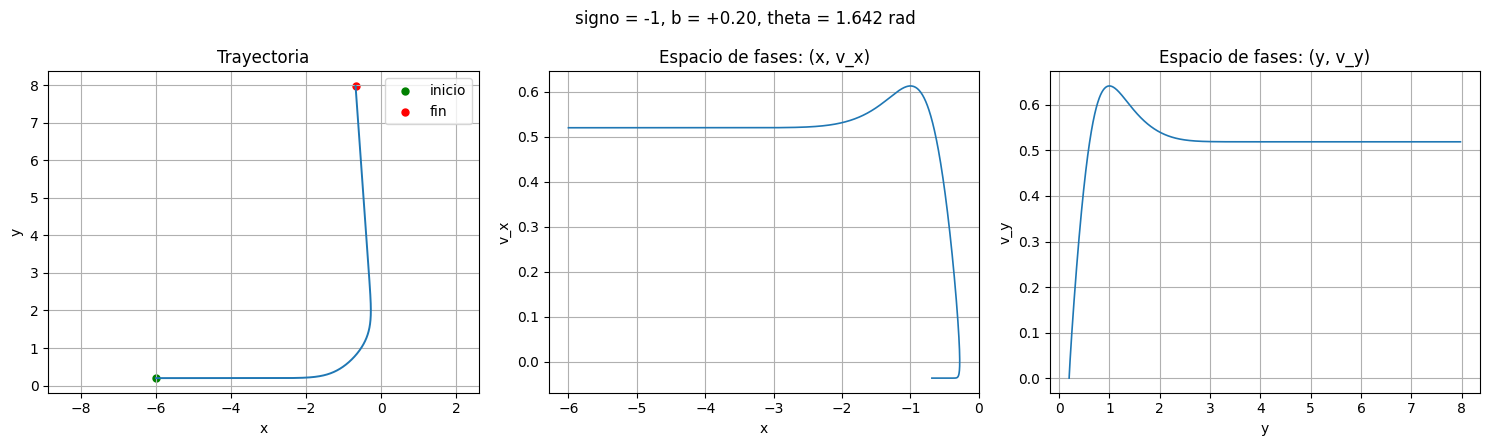

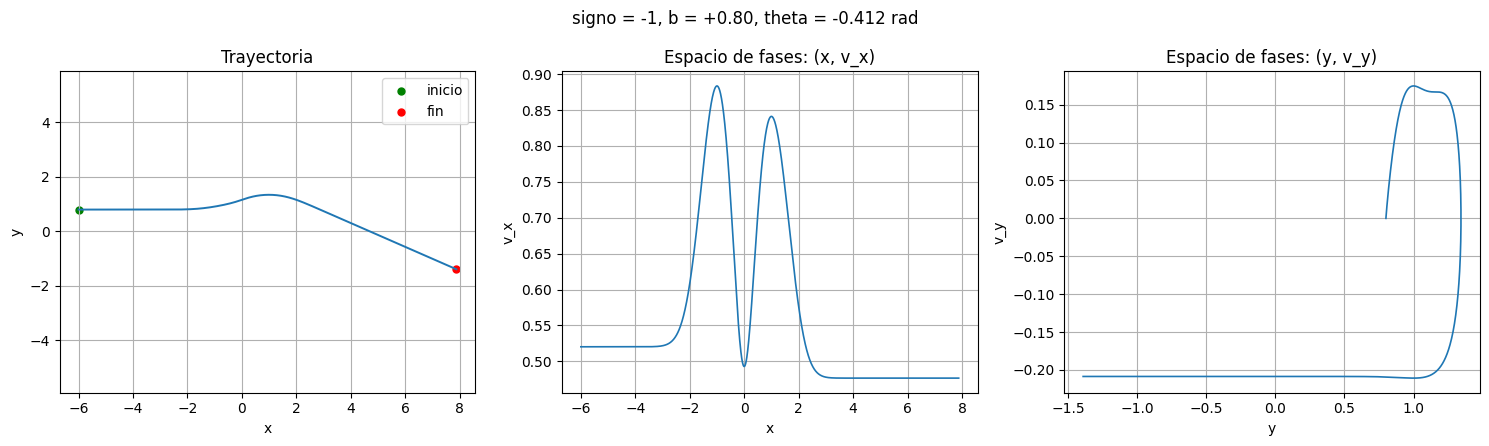

In [11]:
def graficar_trayectoria_y_fase(resultado, titulo=""):
    tiempos = resultado["tiempos"]
    estados = resultado["estados"]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    axes[0].plot(estados[:, 0], estados[:, 1], lw=1.4)
    axes[0].scatter(estados[0, 0], estados[0, 1], c="green", s=25, label="inicio")
    axes[0].scatter(estados[-1, 0], estados[-1, 1], c="red", s=25, label="fin")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    axes[0].set_title("Trayectoria")
    axes[0].axis("equal")
    axes[0].legend()

    axes[1].plot(estados[:, 0], estados[:, 2], lw=1.2)
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("v_x")
    axes[1].set_title("Espacio de fases: (x, v_x)")

    axes[2].plot(estados[:, 1], estados[:, 3], lw=1.2)
    axes[2].set_xlabel("y")
    axes[2].set_ylabel("v_y")
    axes[2].set_title("Espacio de fases: (y, v_y)")

    fig.suptitle(titulo)
    fig.tight_layout()
    plt.show()


energia_muestra = 0.5 * VMAX
casos_muestra = [
    (1.0, -0.8),
    (1.0, -0.2),
    (-1.0, 0.2),
    (-1.0, 0.8),
]

for signo, b in casos_muestra:
    resultado = simular_impactos([b], energia=energia_muestra, signo=signo, **parametros_base)[0]
    graficar_trayectoria_y_fase(
        resultado,
        titulo=(
            f"signo = {signo:+.0f}, b = {b:+.2f}, "
            f"theta = {resultado['theta']:.3f} rad"
        ),
    )

## Primer barrido de ángulo de dispersión y retardo temporal

Esta es la primera versión de los apartados (i), (j), (k) y (l). El muestreo es deliberadamente moderado para ubicar regiones problemáticas antes de refinar alrededor de ellas.

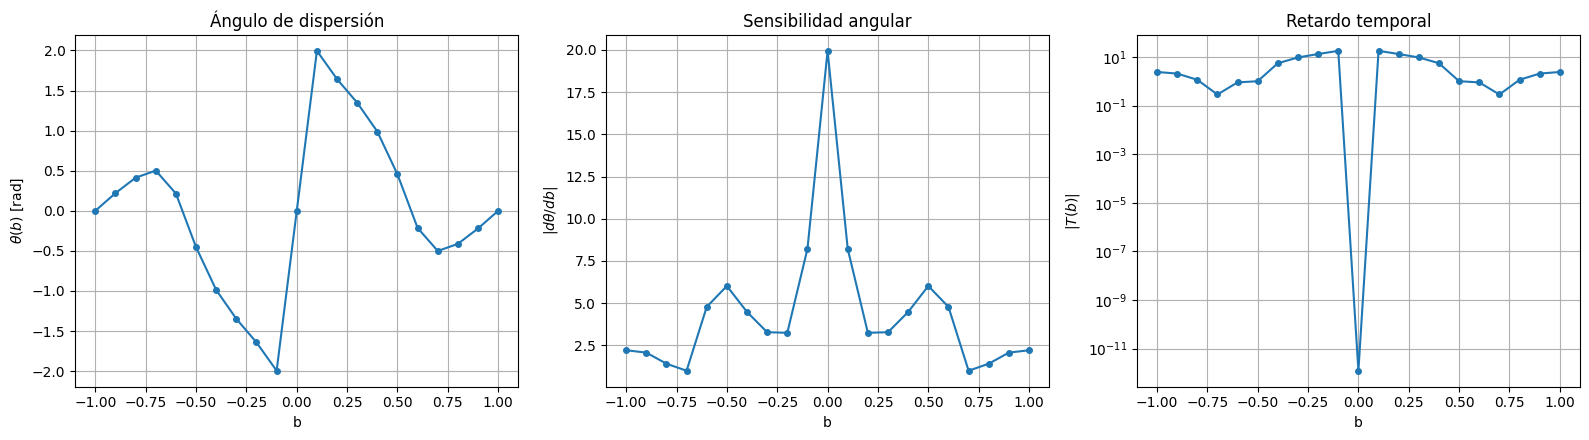

Variación máxima de energía total durante el barrido:
7.44769523830513e-12
Valores de b más sensibles en este barrido inicial:
b = -0.500, theta = -0.453, |dtheta/db| = 6.012e+00, T = 1.007e+00
b = +0.500, theta = +0.453, |dtheta/db| = 6.012e+00, T = 1.007e+00
b = -0.100, theta = -1.995, |dtheta/db| = 8.209e+00, T = 1.795e+01
b = +0.100, theta = +1.995, |dtheta/db| = 8.209e+00, T = 1.795e+01
b = -0.000, theta = -0.000, |dtheta/db| = 1.995e+01, T = 2.274e-13


In [12]:
b_values = np.arange(-1.0, 1.0001, 0.1)
energia_barrido = 0.5 * VMAX
signo_barrido = -1.0

resultados_barrido = simular_impactos(
    b_values,
    energia=energia_barrido,
    signo=signo_barrido,
    **parametros_base,
)

theta_values = np.array([item["theta"] for item in resultados_barrido])
retardos = np.array([item["retardo"] for item in resultados_barrido])
energia_final = np.array([item["energia_final"] for item in resultados_barrido])

derivada_theta = np.gradient(theta_values, b_values)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(b_values, theta_values, "o-", ms=4)
axes[0].set_xlabel("b")
axes[0].set_ylabel(r"$\theta(b)$ [rad]")
axes[0].set_title("Ángulo de dispersión")

axes[1].plot(b_values, np.abs(derivada_theta), "o-", ms=4)
axes[1].set_xlabel("b")
axes[1].set_ylabel(r"$|d\theta/db|$")
axes[1].set_title("Sensibilidad angular")

axes[2].semilogy(b_values, np.abs(retardos) + 1e-12, "o-", ms=4)
axes[2].set_xlabel("b")
axes[2].set_ylabel(r"$|T(b)|$")
axes[2].set_title("Retardo temporal")

fig.tight_layout()
plt.show()

print("Variación máxima de energía total durante el barrido:")
print(np.max(np.abs(energia_final - energia_barrido)))

indices_sensibles = np.argsort(np.abs(derivada_theta))[-5:]
print("Valores de b más sensibles en este barrido inicial:")
for idx in indices_sensibles:
    print(
        f"b = {b_values[idx]:+.3f}, theta = {theta_values[idx]:+.3f}, "
        f"|dtheta/db| = {abs(derivada_theta[idx]):.3e}, T = {retardos[idx]:.3e}"
    )

## Refinamiento local: b → b/10 alrededor de regiones oscilatorias

El primer barrido muestra que la región más sensible se concentra cerca de $b = 0$. Tomamos los 3 valores de mayor $|d\theta/db|$ y repetimos la simulación con un muestreo 10 veces más fino y paso temporal más pequeño, tal como indica el apartado (l).

Centros seleccionados para refinamiento: [-1.00000000e-01 -2.22044605e-16  1.00000000e-01]


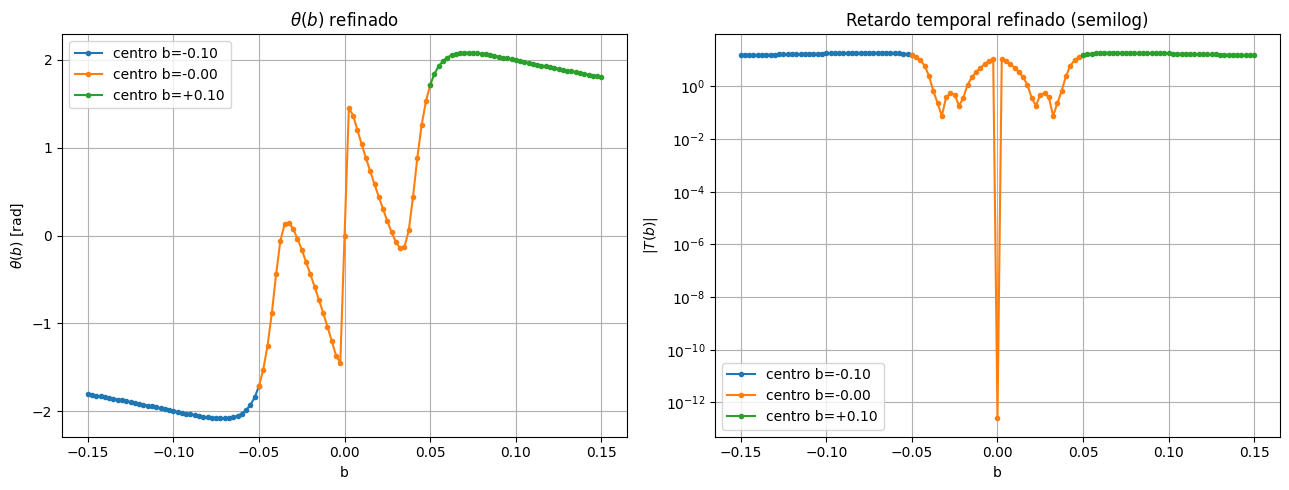

In [13]:
# Tomar los 3 picos con mayor |dθ/db| del barrido inicial
centros_sensibles = b_values[np.argsort(np.abs(derivada_theta))[-3:]]
print("Centros seleccionados para refinamiento:", np.sort(centros_sensibles))

# Parámetros refinados: paso 10x más fino, ventana ±0.05 (= Δb/10)
param_fino = {**parametros_base, "dt": 0.005}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for centro in np.sort(centros_sensibles):
    ancho = 0.05  # ventana de b/10 alrededor del centro
    b_fino = np.linspace(centro - ancho, centro + ancho, 41)
    res_fino = simular_impactos(
        b_fino,
        energia=energia_barrido,
        signo=signo_barrido,
        **param_fino,
    )
    th_fino = np.array([r["theta"] for r in res_fino])
    ret_fino = np.array([r["retardo"] for r in res_fino])
    label = f"centro b={centro:+.2f}"
    axes[0].plot(b_fino, th_fino, "-o", ms=3, label=label)
    axes[1].semilogy(b_fino, np.abs(ret_fino) + 1e-14, "-o", ms=3, label=label)

axes[0].set_xlabel("b")
axes[0].set_ylabel(r"$\theta(b)$ [rad]")
axes[0].set_title(r"$\theta(b)$ refinado")
axes[0].legend()

axes[1].set_xlabel("b")
axes[1].set_ylabel(r"$|T(b)|$")
axes[1].set_title("Retardo temporal refinado (semilog)")
axes[1].legend()

fig.tight_layout()
plt.show()

## Comparación: 4 regímenes (atractivo/repulsivo × E < Vₘₐₓ / E > Vₘₐₓ)

Cubre el apartado (k). Se barre $b \in [-1,1]$ con paso $\Delta b = 0.05$ para las cuatro combinaciones. Las curvas $\theta(b)$ y $T(b)$ permiten ver cómo la captura transitoria y las discontinuidades dependen del régimen energético y del signo del potencial.

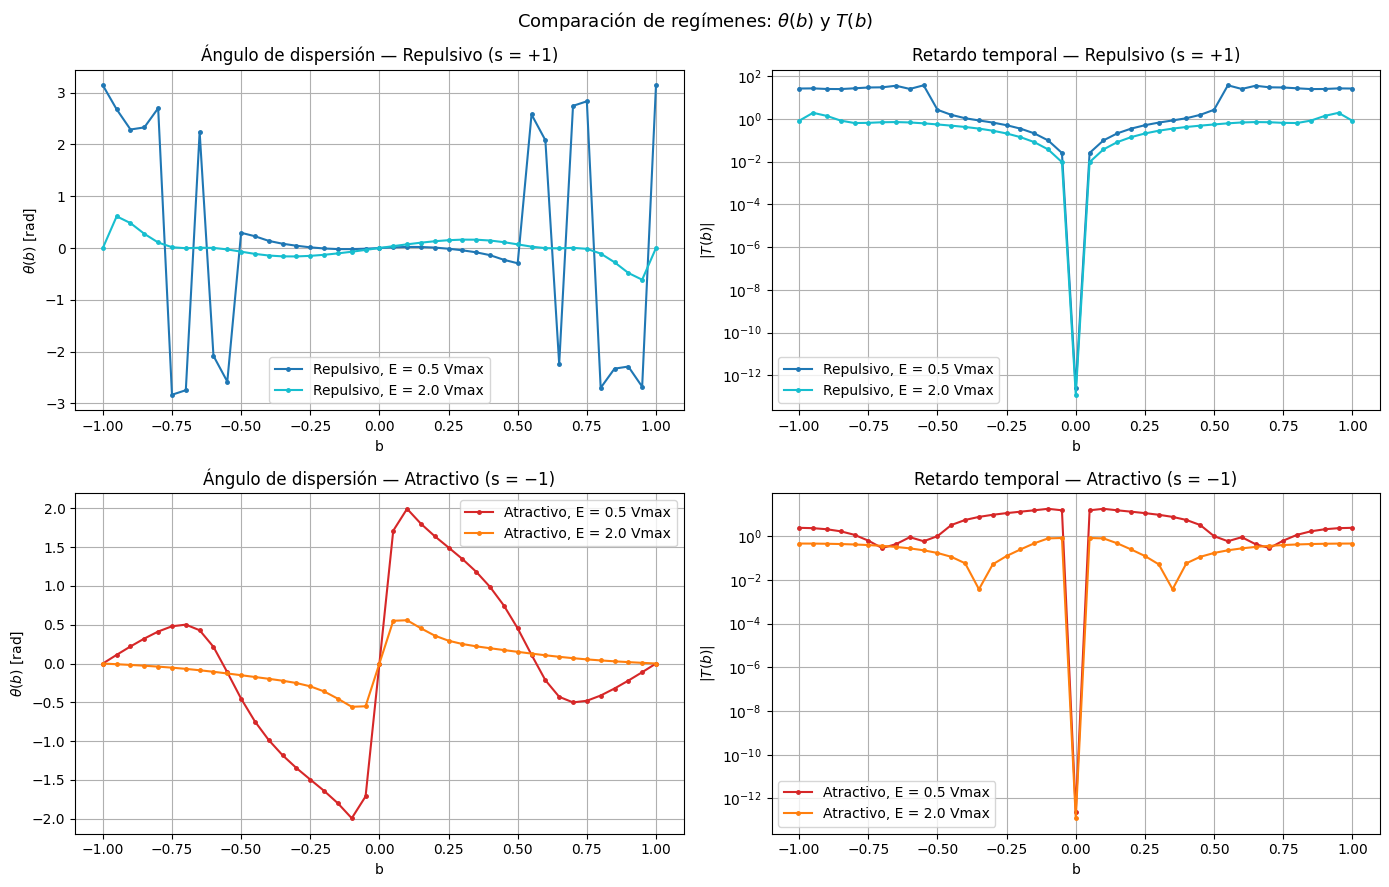

In [14]:
regimenes = [
    {"signo":  1.0, "energia": 0.5 * VMAX, "label": "Repulsivo, E = 0.5 Vmax",  "color": "tab:blue"},
    {"signo":  1.0, "energia": 2.0 * VMAX, "label": "Repulsivo, E = 2.0 Vmax",  "color": "tab:cyan"},
    {"signo": -1.0, "energia": 0.5 * VMAX, "label": "Atractivo, E = 0.5 Vmax",  "color": "tab:red"},
    {"signo": -1.0, "energia": 2.0 * VMAX, "label": "Atractivo, E = 2.0 Vmax",  "color": "tab:orange"},
]

b_comp = np.arange(-1.0, 1.0001, 0.05)
param_comp = {**parametros_base, "dt": 0.005}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(r"Comparación de regímenes: $\theta(b)$ y $T(b)$", fontsize=13)

for reg in regimenes:
    resultados = simular_impactos(
        b_comp,
        energia=reg["energia"],
        signo=reg["signo"],
        **param_comp,
    )
    th = np.array([r["theta"] for r in resultados])
    ret = np.array([r["retardo"] for r in resultados])
    kw = {"label": reg["label"], "color": reg["color"], "lw": 1.5, "marker": "o", "ms": 2.5}

    # fila 0 = repulsivo, fila 1 = atractivo
    row = 0 if reg["signo"] > 0 else 1
    axes[row, 0].plot(b_comp, th, **kw)
    axes[row, 1].semilogy(b_comp, np.abs(ret) + 1e-14, **kw)

for row, titulo in enumerate(["Repulsivo (s = +1)", "Atractivo (s = −1)"]):
    axes[row, 0].set_xlabel("b")
    axes[row, 0].set_ylabel(r"$\theta(b)$ [rad]")
    axes[row, 0].set_title(f"Ángulo de dispersión — {titulo}")
    axes[row, 0].legend()
    axes[row, 1].set_xlabel("b")
    axes[row, 1].set_ylabel(r"$|T(b)|$")
    axes[row, 1].set_title(f"Retardo temporal — {titulo}")
    axes[row, 1].legend()

fig.tight_layout()
plt.show()

## Observaciones y discusión

### Apartado (h) — Espacio de fases

Las figuras de $(x, v_x)$ y $(y, v_y)$ muestran que, a diferencia de los estados ligados, las trayectorias **no forman curvas cerradas**: la partícula entra con un valor de energía cinética, transfiere parte de ella al potencial durante la interacción, y sale con una dirección distinta. En el caso atractivo y con energía próxima a $V_{\max}$, el paso de la partícula por la zona de los máximos del potencial puede generar un giro cerrado temporal (captura transitoria), que se manifiesta como un bucle en el espacio de fases antes de que la trayectoria se abra.

### Apartado (j) — Discontinuidades en $d\theta/db$

La sección eficaz diferencial clásica es proporcional a $|b / \sin\theta \cdot (d\theta/db)^{-1}|$. Cuando $d\theta/db \to \infty$, la sección eficaz se anula (mínimo clásico). Más relevante es la situación inversa: cuando $\theta(b)$ cambia bruscamente de signo al cruzar $b=0$, hay una **discontinuidad** en la curva que implica que trayectorias arbitrariamente cercanas salen en direcciones opuestas. Esto no proviene de una singularidad de la fuerza, sino de la **sensibilidad exponencial** a las condiciones iniciales: la partícula queda atrapada transitoriamente entre dos máximos del potencial y pequeñas variaciones en $b$ determinan por cuál de los canales escapa.

### Retardo temporal y comportamiento caótico

La gráfica semilogarítmica de $T(b)$ muestra un mínimo muy profundo alrededor de $b=0$: la partícula que pasa por el centro de simetría apenas interactúa con el potencial y se desplaza prácticamente en línea recta (no hay retardo). En cambio, para $b$ próximo a los máximos del potencial la partícula puede quedar atrapada muchos períodos antes de escapar, generando retardos mucho mayores. La estructura oscilatoria de $T(b)$ en escala logarítmica es un indicador clásico de **dispersión caótica**.

### Comparación entre regímenes

| Régimen | Característica principal |
|---|---|
| Repulsivo, $E > V_{\max}$ | La partícula siempre supera el potencial; $\theta(b)$ es suave y monótona |
| Repulsivo, $E < V_{\max}$ | Algunas trayectorias son reflejadas; aparecen picos en $|d\theta/db|$ |
| Atractivo, $E > V_{\max}$ | La partícula atraviesa los pozos; dispersión activa pero relativamente suave |
| Atractivo, $E < V_{\max}$ | Captura transitoria posible; máxima complejidad en $\theta(b)$ y $T(b)$ |